In [1]:
import pandas as pd

data = pd.read_csv("clean_spotify_data.csv")

In [2]:
data.head()

,title,rank,date,artist,url,region,chart,trend,track_id,track_name,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,6mICuAdrwEjh6Y6lroV2Kg,Chantaje (feat. Maluma),...,8.0,-2.921,0.0,0.0776,0.18700,0.000030,0.159,0.907,102.034,195840.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,7DM4BPaS7uofFul3ywMe46,Vente Pa' Ca,...,11.0,-4.070,0.0,0.2260,0.00431,0.000017,0.101,0.533,99.935,259196.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,3AEZUABDXNtecAOSC1qTfo,Reggaetón Lento (Bailemos),...,4.0,-3.073,0.0,0.0502,0.40000,0.000000,0.176,0.710,93.974,222560.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,6rQSrBHf7HlZjtcMZ4S4bO,Safari,...,0.0,-4.361,1.0,0.3260,0.55100,0.000003,0.126,0.555,180.044,205600.0
4,Traicionera,6,2017-01-01,Sebastian Yatra,https://open.spotify.com/track/5J1c3M4EldCfNxX...,Argentina,top200,MOVE_DOWN,5J1c3M4EldCfNxXwrwt8mT,Traicionera,...,11.0,-4.933,1.0,0.0638,0.14200,0.000000,0.219,0.661,91.012,228467.0


In [3]:
data.columns

Index(['title', 'rank', 'date', 'artist', 'url', 'region', 'chart', 'trend',
       'track_id', 'track_name', 'track_artist', 'track_popularity',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='str')

In [4]:
data.shape

(8705312, 26)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8705312 entries, 0 to 8705311
Data columns (total 26 columns):
 #   Column             Dtype  
---  ------             -----  
 0   title              str    
 1   rank               int64  
 2   date               str    
 3   artist             str    
 4   url                str    
 5   region             str    
 6   chart              str    
 7   trend              str    
 8   track_id           str    
 9   track_name         str    
 10  track_artist       str    
 11  track_popularity   float64
 12  playlist_genre     str    
 13  playlist_subgenre  str    
 14  danceability       float64
 15  energy             float64
 16  key                float64
 17  loudness           float64
 18  mode               float64
 19  speechiness        float64
 20  acousticness       float64
 21  instrumentalness   float64
 22  liveness           float64
 23  valence            float64
 24  tempo              float64
 25  duration_ms        float64
dt

In [7]:
data["date"] = pd.to_datetime(data["date"])
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 8705312 entries, 0 to 8705311
Data columns (total 26 columns):
 #   Column             Dtype         
---  ------             -----         
 0   title              str           
 1   rank               int64         
 2   date               datetime64[us]
 3   artist             str           
 4   url                str           
 5   region             str           
 6   chart              str           
 7   trend              str           
 8   track_id           str           
 9   track_name         str           
 10  track_artist       str           
 11  track_popularity   float64       
 12  playlist_genre     str           
 13  playlist_subgenre  str           
 14  danceability       float64       
 15  energy             float64       
 16  key                float64       
 17  loudness           float64       
 18  mode               float64       
 19  speechiness        float64       
 20  acousticness       float64       
 

In [10]:
data["year"] = data["date"].dt.year

data[["date", "year"]].head()

,date,year
0,2017-01-01,2017
1,2017-01-01,2017
2,2017-01-01,2017
3,2017-01-01,2017
4,2017-01-01,2017


In [13]:
data["month"] = data["date"].dt.month
data[["date", "month"]].tail()

,date,month
8705307,2021-07-31,7
8705308,2021-07-31,7
8705309,2021-07-31,7
8705310,2021-07-31,7
8705311,2021-07-31,7


In [11]:
data["year"].value_counts().sort_index()

year
2017    1727031
2018    2162631
2019    2778739
2020    1528519
2021     508392
Name: count, dtype: int64

In [14]:
data["duration_ms"].isna().sum()

np.int64(0)

In [15]:
data.groupby("year")["track_popularity"].mean()

year
2017    54.950876
2018    66.181269
2019    77.707067
2020    84.066729
2021    82.602930
Name: track_popularity, dtype: float64

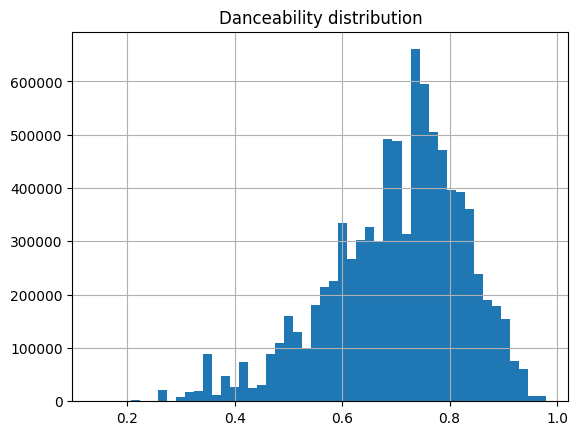

In [17]:
from matplotlib import pyplot as plt 
data["danceability"].hist(bins=50)
plt.title("Danceability distribution")
plt.show()

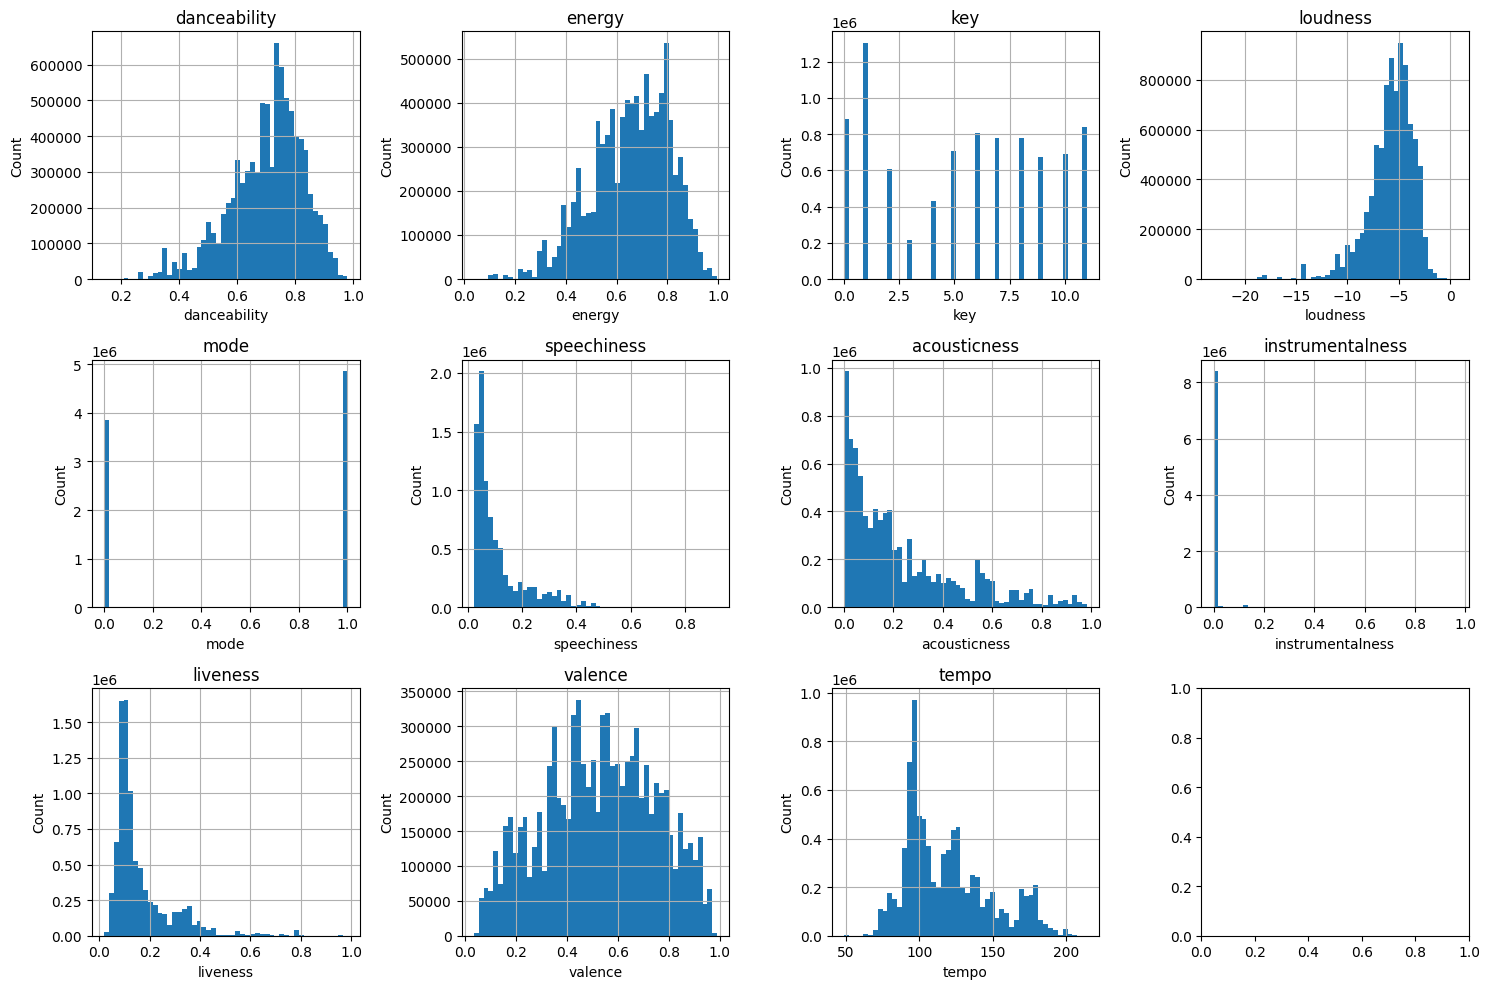

In [22]:
features = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(data[col], bins=50)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

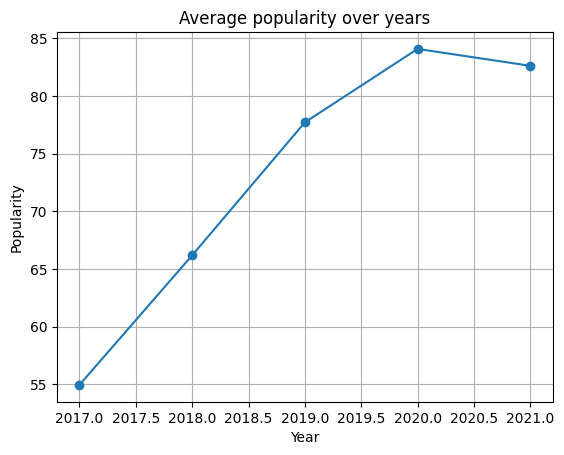

In [23]:
data.groupby("year")["track_popularity"].mean().plot(marker = 'o')
plt.title("Average popularity over years")
plt.xlabel("Year")
plt.ylabel("Popularity")
plt.grid(True)
plt.show()

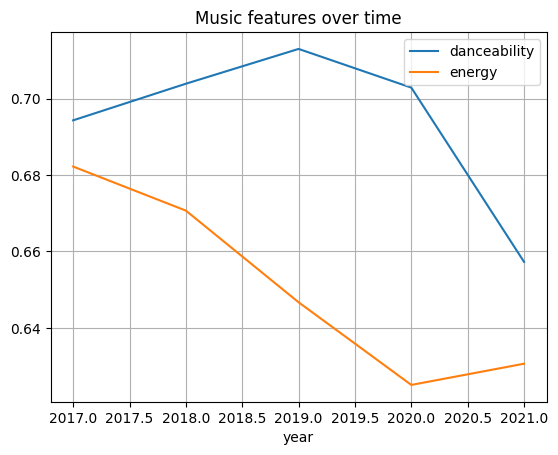

In [24]:
data.groupby("year")["danceability"].mean().plot(label="danceability")
data.groupby("year")["energy"].mean().plot(label="energy")

plt.legend()
plt.title("Music features over time")
plt.grid(True)
plt.show()

In [86]:
df_sample = data[data["month"] == 12]  

top_tracks = df_sample.sort_values("track_popularity", ascending=False).groupby("year").head(3)

results_top = pd.DataFrame(top_tracks[["year", "track_name", "track_artist", "track_popularity"]])

In [ ]:
results_top

In [34]:
data[["danceability", "energy"]].corr()


,danceability,energy
danceability,1.000000,0.044818
energy,0.044818,1.000000


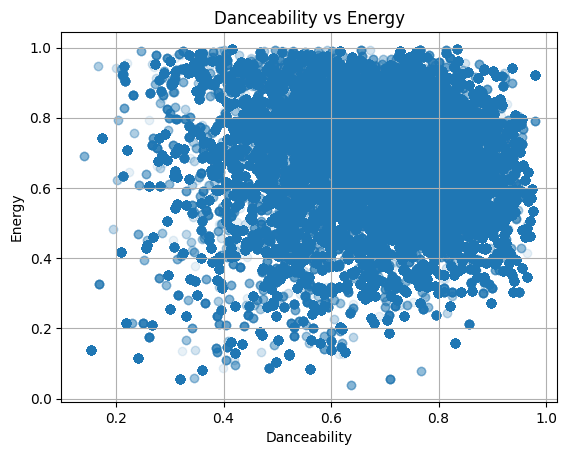

In [35]:

plt.scatter(data["danceability"], data["energy"], alpha=0.1)
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("Danceability vs Energy")
plt.grid(True)
plt.show()

In [36]:
data['region'].unique()

<StringArray>
[           'Argentina',            'Australia',              'Austria',
              'Belgium',              'Bolivia',               'Brazil',
             'Bulgaria',               'Canada',                'Chile',
             'Colombia',           'Costa Rica',       'Czech Republic',
              'Denmark',   'Dominican Republic',              'Ecuador',
          'El Salvador',              'Estonia',              'Finland',
               'France',              'Germany',               'Global',
               'Greece',            'Guatemala',             'Honduras',
            'Hong Kong',              'Hungary',              'Iceland',
            'Indonesia',              'Ireland',                'Italy',
                'Japan',               'Latvia',            'Lithuania',
           'Luxembourg',             'Malaysia',               'Mexico',
          'Netherlands',          'New Zealand',            'Nicaragua',
               'Norway',             

In [39]:
countries = ["Poland", "United States", "Germany", "Brazil", "Japan"]


top_tracks = data[data["region"].isin(countries)]\
    .sort_values("rank")\
    .groupby("region")\
    .head(3)

top_tracks[["region", "track_name", "track_artist", "rank"]]

,region,track_name,track_artist,rank
4858604,Poland,Shape of You,Ed Sheeran,1
6770586,Poland,Dance Monkey,Tones and I,1
3415516,Poland,Señorita,Shawn Mendes,1
3414963,Brazil,Surtada - Remix Brega Funk,Dadá Boladão,1
5768702,United States,Passionfruit,Drake,1
3408666,United States,Circles,Post Malone,1
408215,United States,Nice For What,Drake,1
5769489,Brazil,Shape of You,Ed Sheeran,1
6769130,Germany,Dance Monkey,Tones and I,1
6768818,Germany,Roller,Apache 207,1


In [41]:
shape = data[data["track_name"] == "Shape of You"].copy()

shape[["region", "track_name", "track_artist", "rank", "date", "track_popularity"]].head()

,region,track_name,track_artist,rank,date,track_popularity
5161,Argentina,Shape of You,Ed Sheeran,58,2018-03-01,86.0
5235,Australia,Shape of You,Ed Sheeran,40,2018-03-01,86.0
5346,Austria,Shape of You,Ed Sheeran,60,2018-03-01,86.0
5419,Belgium,Shape of You,Ed Sheeran,32,2018-03-01,86.0
5520,Bolivia,Shape of You,Ed Sheeran,46,2018-03-01,86.0


In [71]:
shape_best = (
    shape.sort_values(["region", "rank", "date"]).groupby("region", as_index=False).first()
)

results_shape = pd.DataFrame(shape_best[["region", "track_name", "track_artist", "rank", "track_popularity", "date"]].sort_values("rank"))

In [74]:
results_shape[results_shape['rank'] == 1].count()

region              57
track_name          57
track_artist        57
rank                57
track_popularity    57
date                57
dtype: int64

In [49]:
shape_plot = shape_best.sort_values("rank")
max_rank = shape_plot["rank"].max()

shape_plot["score"] = max_rank - shape_plot["rank"] + 1



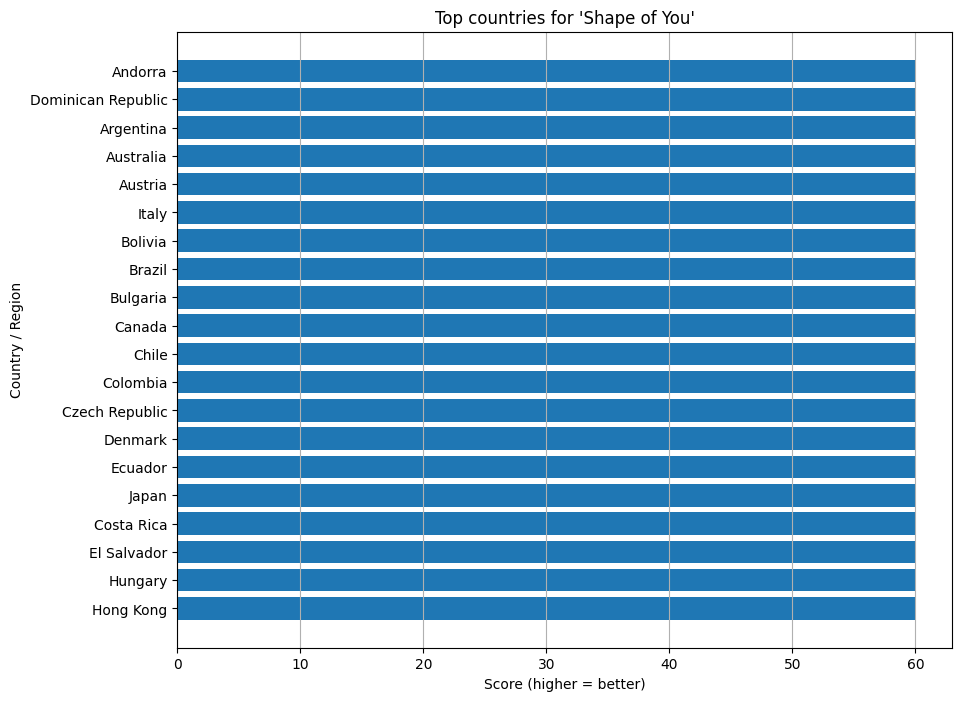

In [61]:
top_shape = shape_plot.sort_values("score", ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_shape["region"], top_shape["score"])
plt.xlabel("Score (higher = better)")
plt.ylabel("Country / Region")
plt.title("Top countries for 'Shape of You'")
plt.grid(True, axis="x")
plt.gca().invert_yaxis()
plt.show()

In [75]:
shape_time = data[data["track_name"] == "Shape of You"]
shape_top10 = shape_time[shape_time["rank"] <= 10]

shape_top10.groupby("region")["date"].count().sort_values(ascending=False)

region
Japan                 697
Hong Kong             304
Colombia              290
Nicaragua             289
Czech Republic        281
El Salvador           274
Peru                  274
Costa Rica            272
Taiwan                270
Ecuador               269
Global                264
Hungary               263
Bolivia               262
Turkey                261
Honduras              260
Poland                259
Switzerland           253
France                248
Singapore             245
Dominican Republic    240
Portugal              240
Uruguay               235
Belgium               231
Greece                230
Brazil                230
Malaysia              227
Philippines           226
Panama                226
Argentina             225
Luxembourg            218
Bulgaria              214
Indonesia             212
Guatemala             212
Chile                 208
Mexico                206
Iceland               200
Paraguay              199
Spain                 198
Slova

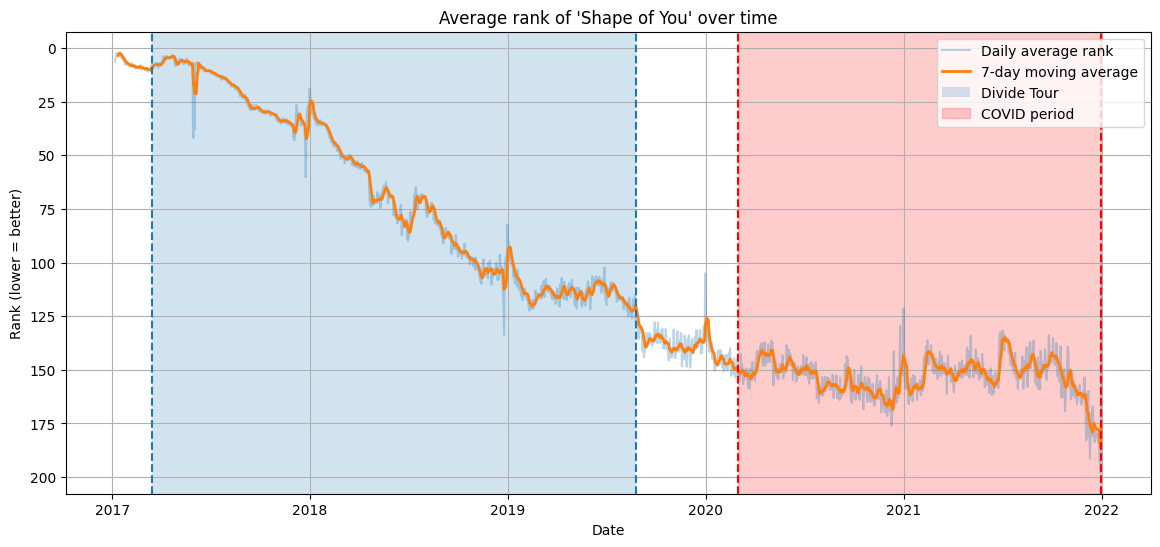

In [89]:
daily_rank = shape_time.groupby("date")["rank"].mean()
smoothed = daily_rank.rolling(window=7).mean()

divide_start = pd.to_datetime("2017-03-16")
divide_end = pd.to_datetime("2019-08-26")

covid_start = pd.to_datetime("2020-03-01")
covid_end = pd.to_datetime("2021-12-31")


plt.figure(figsize=(14, 6))

plt.plot(daily_rank, alpha=0.3, label="Daily average rank")
plt.plot(smoothed, linewidth=2, label="7-day moving average")
plt.axvline(divide_start, linestyle="--")
plt.axvline(divide_end, linestyle="--")
plt.axvspan(divide_start, divide_end, alpha=0.2, label="Divide Tour")
plt.axvspan(covid_start, covid_end, alpha=0.2, color="red", label="COVID period")

plt.axvline(covid_start, linestyle="--", color="red")
plt.axvline(covid_end, linestyle="--", color="red")
plt.gca().invert_yaxis()  

plt.xlabel("Date")
plt.ylabel("Rank (lower = better)")
plt.title("Average rank of 'Shape of You' over time")
plt.legend()
plt.grid(True)

plt.show()

In [78]:
corr = data.corr(numeric_only=True)

corr["track_popularity"].sort_values(ascending=False)

track_popularity    1.000000
year                0.441288
acousticness        0.098472
key                 0.063475
rank                0.063181
month               0.049517
instrumentalness    0.039335
speechiness         0.017785
valence            -0.000012
danceability       -0.006123
mode               -0.013525
liveness           -0.015092
tempo              -0.033537
duration_ms        -0.041323
loudness           -0.064027
energy             -0.131211
Name: track_popularity, dtype: float64

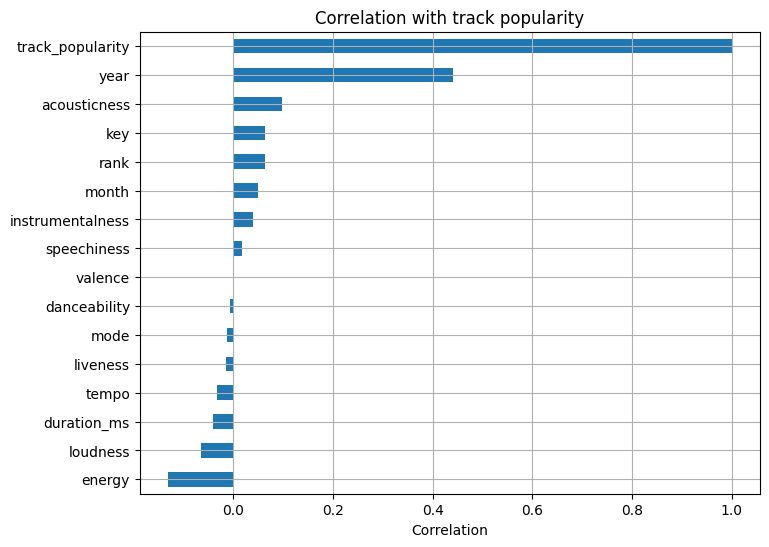

In [79]:
corr_pop = corr["track_popularity"].sort_values()

plt.figure(figsize=(8,6))
corr_pop.plot(kind="barh")

plt.title("Correlation with track popularity")
plt.xlabel("Correlation")
plt.grid(True)

plt.show()

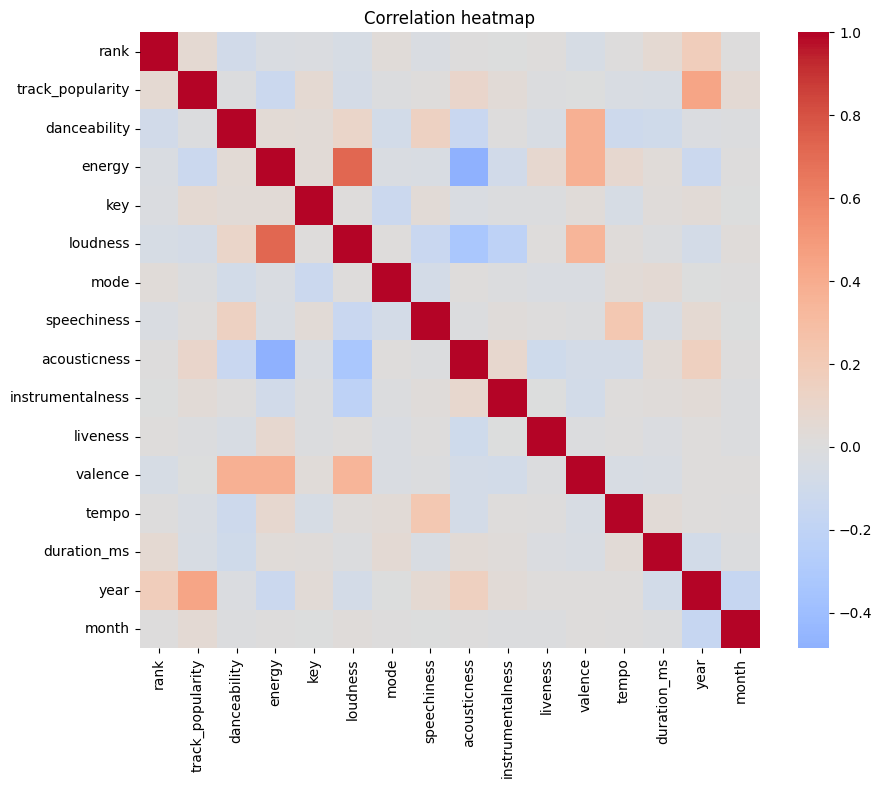

In [80]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

In [81]:
artist_pop = data.groupby("track_artist")["track_popularity"].mean().reset_index()
artist_pop.columns = ["track_artist", "artist_popularity_est"]

In [82]:
data_with_artist = data.merge(artist_pop, on="track_artist")

In [83]:
data_with_artist[["artist_popularity_est", "track_popularity"]].corr()

,artist_popularity_est,track_popularity
artist_popularity_est,1.000000,0.638756
track_popularity,0.638756,1.000000


In [84]:
data[["track_popularity","danceability","energy", "tempo","loudness"]].kurtosis()

track_popularity    2.161762
danceability        0.440164
energy             -0.100077
tempo              -0.235761
loudness            4.663872
dtype: float64

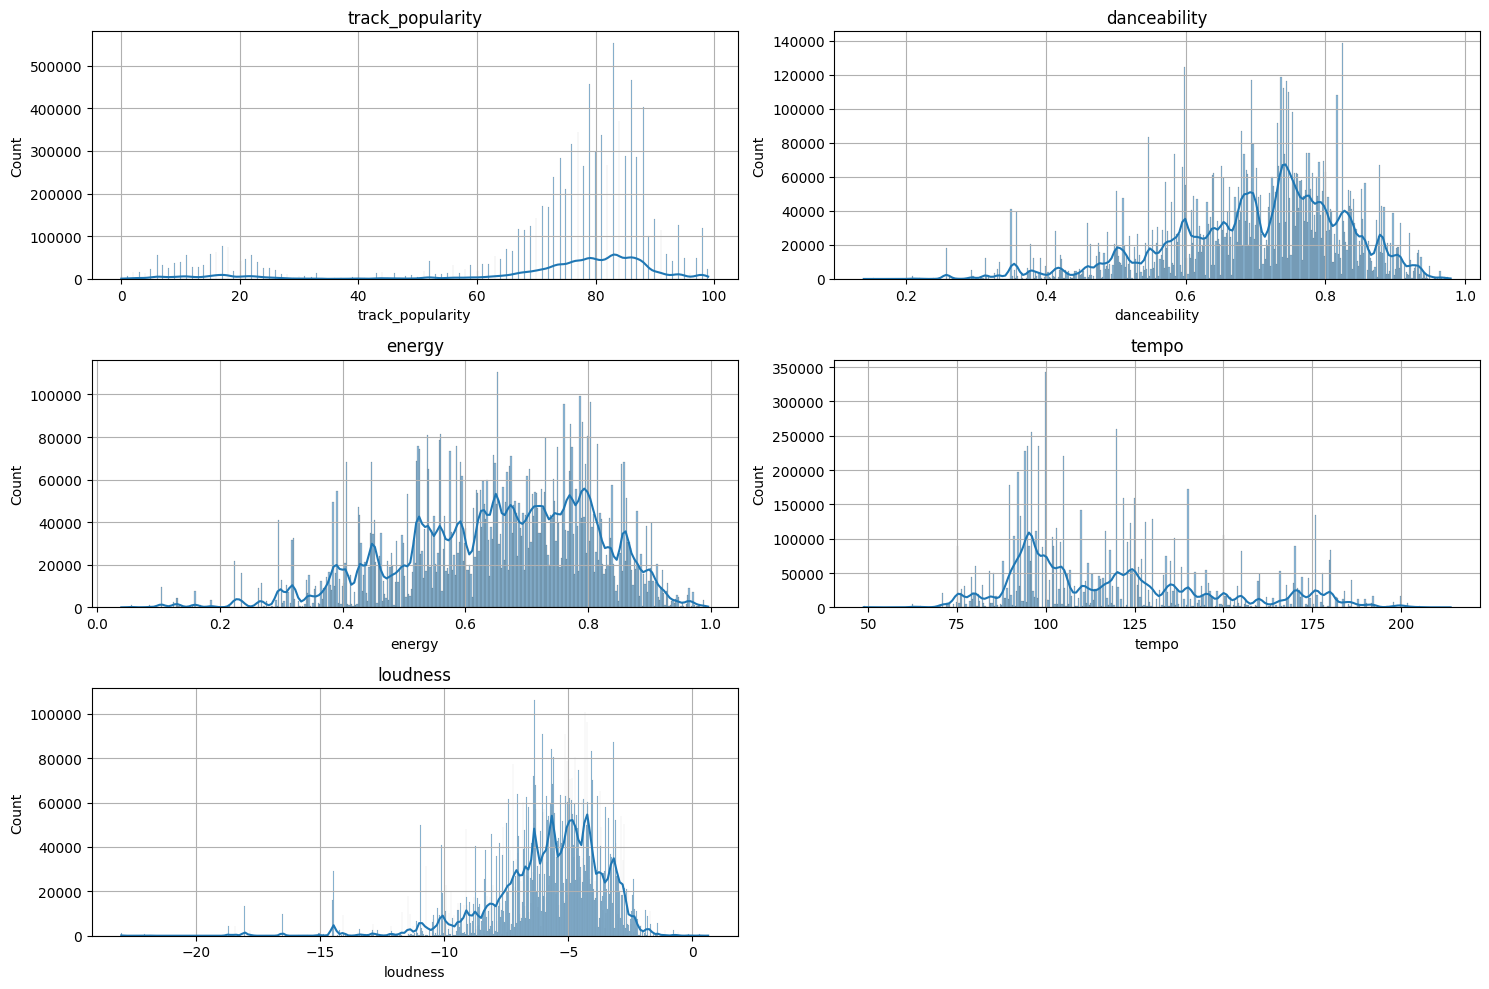

In [85]:
cols = ["track_popularity", "danceability", "energy", "tempo", "loudness"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data[col], kde=True)
    plt.title(f"{col}")
    plt.grid(True)

plt.tight_layout()
plt.show()

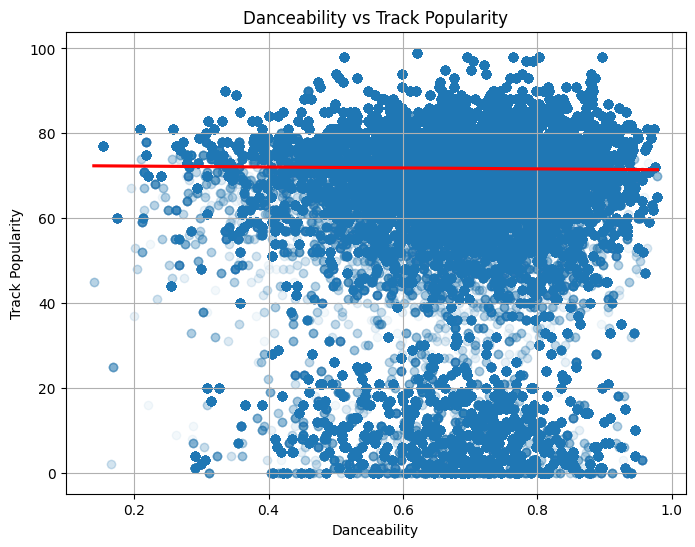

In [87]:
plt.figure(figsize=(8,6))

sns.regplot( x="danceability",y="track_popularity",data=data,scatter_kws={"alpha":0.05},line_kws={"color": "red"})

plt.xlabel("Danceability")
plt.ylabel("Track Popularity")
plt.title("Danceability vs Track Popularity")
plt.grid(True)

plt.show()

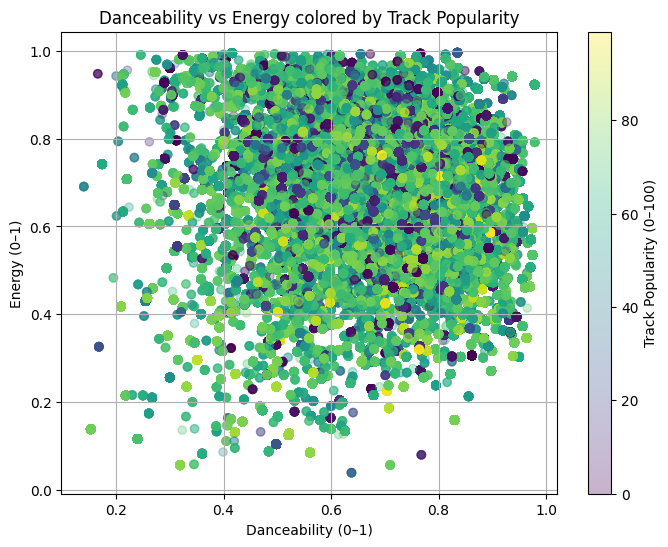

In [90]:
plt.figure(figsize=(8,6))

sc = plt.scatter(
    data["danceability"],
    data["energy"],
    c=data["track_popularity"],
    alpha=0.3
)

plt.xlabel("Danceability (0–1)")
plt.ylabel("Energy (0–1)")
plt.title("Danceability vs Energy colored by Track Popularity")

cbar = plt.colorbar(sc)
cbar.set_label("Track Popularity (0–100)")

plt.grid(True)
plt.show()

Przed COVID:
mode
0.0    0.447104
1.0    0.552896
Name: proportion, dtype: float64

W czasie COVID:
mode
0.0    0.423845
1.0    0.576155
Name: proportion, dtype: float64

Porównanie udziałów:
              pre_covid     covid
Minor (moll)   0.447104  0.423845
Major (dur)    0.552896  0.576155


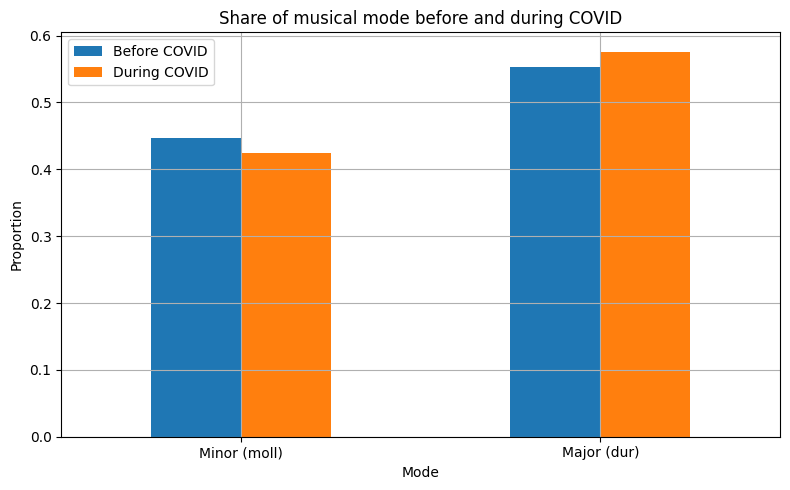

In [91]:
pre_covid = data[(data["date"] >= "2017-01-01") & (data["date"] < "2020-03-01")].copy()
covid = data[(data["date"] >= "2020-03-01") & (data["date"] <= "2021-12-31")].copy()


pre_mode = pre_covid["mode"].value_counts(normalize=True).sort_index()
covid_mode = covid["mode"].value_counts(normalize=True).sort_index()

print("Przed COVID:")
print(pre_mode)

print("\nW czasie COVID:")
print(covid_mode)


mode_compare = pd.DataFrame({
    "pre_covid": pre_mode,
    "covid": covid_mode
})

mode_compare.index = ["Minor (moll)", "Major (dur)"]

print("\nPorównanie udziałów:")
print(mode_compare)

# wykres
ax = mode_compare.plot(
    kind="bar",
    figsize=(8, 5),
    grid=True
)

plt.title("Share of musical mode before and during COVID")
plt.xlabel("Mode")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(["Before COVID", "During COVID"])
plt.tight_layout()
plt.show()

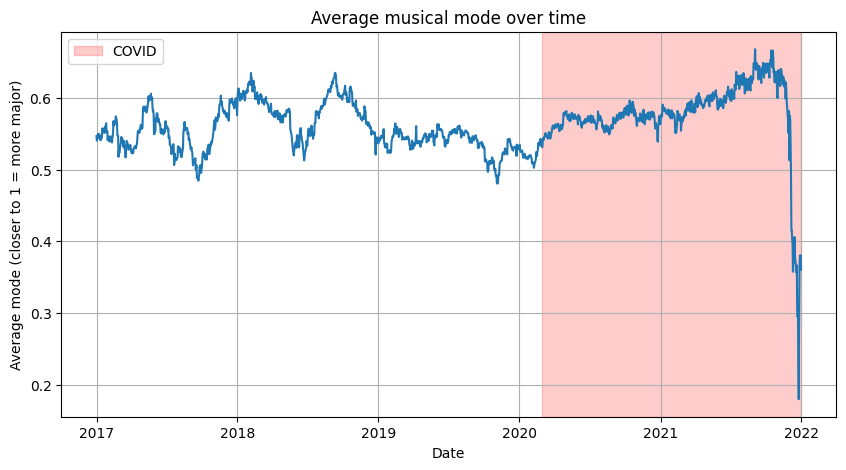

In [92]:
mode_time = data.groupby(data["date"])["mode"].mean()

plt.figure(figsize=(10,5))
plt.plot(mode_time.index, mode_time.values)

plt.axvspan("2020-03-01", "2021-12-31", alpha=0.2, color="red", label="COVID")

plt.title("Average musical mode over time")
plt.xlabel("Date")
plt.ylabel("Average mode (closer to 1 = more major)")
plt.legend()
plt.grid(True)

plt.show()